In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy 

data_paths = []
# Cold flow Attempt 1
# data_paths.append(Path(r"C:\Users\elyse\Downloads\04\15-50-33_data.csv")) 
# Cold flow Attempt 2
# data_paths.append(Path(r"C:\Users\elyse\Downloads\09\13-07-57_data.csv"))
# data_paths.append(Path(r"C:\Users\elyse\Downloads\09\14-12-13_data.csv"))
data_paths.append(Path(r"C:\Users\elyse\Downloads\11\11-16-30_data.csv"))

# Cold flow Attempt 2 Actuation Data
actuation_data = []
# actuation_data.append(Path(r"C:\Users\elyse\Downloads\09\13-03-43_actuation_data.csv"))
# actuation_data.append(Path(r"C:\Users\elyse\Downloads\09\13-14-13_actuation_data.csv"))
actuation_data.append(Path(r"C:\Users\elyse\Downloads\11\11-16-03_actuation_data.csv"))


In [ ]:
# from IPython.display import display

# df = pd.read_csv(data_paths[1], header=0)
# data_matrix = df.to_numpy()

# df["t_rel"] = df.t_wall - df.t_wall.min()

# t, value, raw_value, voltage, units, type = {}, {}, {}, {}, {}, {}
# dt = []
# plots_by_type = {}

# for name, g in df.groupby("sensor_name"):
#     name = name.strip()
#     g = g.sort_values("t_rel")
#     t[name] = g.t_rel.to_numpy()
#     value[name] = g.value.to_numpy()
#     units[name] = g.units.iloc[0]
#     type[name] = g.sensor_kind.iloc[0]
    
#     mask = (t[name] > 2000) & (t[name] < 2300)
#     t[name] = t[name][mask]
#     value[name] = value[name][mask]

#     if len(t[name]) == 0:
#         continue

#     sensor_type = type[name]
#     if sensor_type not in plots_by_type:
#         fig, ax = plt.subplots(figsize=(10, 6))
#         ax.set_xlabel("time (s)")
#         ax.set_ylabel(f"{sensor_type} ({units[name]})")
#         ax.set_title(f"{sensor_type.title()} vs Time")
#         ax.grid(True)
#         plots_by_type[sensor_type] = {
#             "figure": fig,
#             "ax": ax,
#         }

#     plots_by_type[sensor_type]["ax"].plot(t[name], value[name], label=name)

# for sensor_type, plot_info in plots_by_type.items():
#     handles, labels = plot_info["ax"].get_legend_handles_labels()
#     if not labels:
#         plt.close(plot_info["figure"])
#         continue
#     plot_info["ax"].legend(handles, labels)
#     plot_info["figure"].tight_layout()
#     display(plot_info["figure"])
#     plt.close(plot_info["figure"])

In [16]:
import ast
import pandas as pd
import numpy as np

bad_rows_data = []
bad_rows_actuation = []

df = pd.read_csv(
    data_paths[0],
    header=0,
    engine="python",
    on_bad_lines=lambda row: bad_rows_data.append(row) or None,
)

da = pd.read_csv(
    actuation_data[0],
    header=0,
    engine="python",
    on_bad_lines=lambda row: bad_rows_actuation.append(row) or None,
)

print("Data shape:", df.shape)
print("Actuation shape:", da.shape)

print("Bad rows in data file:", len(bad_rows_data))
if bad_rows_data:
    print("First bad row:")
    print(bad_rows_data[0])

print("Bad rows in actuation file:", len(bad_rows_actuation))
if bad_rows_actuation:
    print("First bad row:")
    print(bad_rows_actuation[0])


data_matrix = df.to_numpy()
actuation_matrix = da.to_numpy()


def parse_wall_time(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        return numeric.astype(float), "numeric"

    timestamps = pd.to_datetime(series, errors="coerce")
    if timestamps.notna().any():
        return timestamps, "datetime"

    raise ValueError(
        "t_wall column could not be parsed as numeric or datetime values"
    )


def relative_seconds(time_values, time_kind, t0):
    if time_kind == "datetime":
        return (time_values - t0).dt.total_seconds()
    return time_values - t0


def format_actuation_label(valve_id, target_state=None, target_angle=None):
    if pd.notna(target_state) and str(target_state).strip():
        return f"{valve_id} {target_state}"
    if pd.notna(target_angle):
        return f"{valve_id} {target_angle:g} deg"
    return str(valve_id)


df_wall_time, df_time_kind = parse_wall_time(df["t_wall"])
da_wall_time, da_time_kind = parse_wall_time(da["t_wall"])

if df_time_kind != da_time_kind:
    raise ValueError(
        "df and da t_wall columns were parsed as different time types"
    )

shared_t0 = min(
    df_wall_time.dropna().min(),
    da_wall_time.dropna().min(),
)

df["t_rel"] = relative_seconds(df_wall_time, df_time_kind, shared_t0)
da["t_rel"] = relative_seconds(da_wall_time, da_time_kind, shared_t0)

print()
print("df t_rel range:", df["t_rel"].min(), "to", df["t_rel"].max())
print("da t_rel range:", da["t_rel"].min(), "to", da["t_rel"].max())

mask_start = 4475
mask_end = 4525

rows_in_window = (
    (df["t_rel"] > mask_start)
    & (df["t_rel"] < mask_end)
).sum()

print(
    f"Rows between {mask_start}s and {mask_end}s:",
    rows_in_window
)

print("\nSensors present:")
print(df["sensor_name"].unique())

Data shape: (283165, 10)
Actuation shape: (31, 7)
Bad rows in data file: 0
Bad rows in actuation file: 0

df t_rel range: 1624.0728375911713 to 2208.9953048229218
da t_rel range: 0.0 to 2098.683802127838
Rows between 4475s and 4525s: 0

Sensors present:
<StringArray>
['FI-PT', 'CC-PT', 'OM-PT', 'FM-PT', 'FT-PT', 'OI-PT',  'E-LC', 'LF-PT',
  'N-LC', 'WM-PT', 'OF-PT', 'OT-PT', 'FM-FM', 'OM-FM', 'XF-PT']
Length: 15, dtype: str


df columns: ['sensor_name', 'sensor_kind', 't_monotonic', 't_wall', 'Voltage 1', 'Voltage 2', 'value', 'units', 'filtered_value', 'source']
da columns: ['valve_id', 'valve_type', 'target_state', 'target_angle', 'dt', 't_wall', 'action_type']
df shape: (2245253, 10)
da shape: (33, 7)
df t_rel range: 0.0 to 4512.040861606598
da t_rel range: 671.1522674560547 to 4376.215637683868
rows in mask: 24609
number of plot groups: 11
plot groups: ['CC-PT', 'E-LC', 'Injector PT', 'FM-FM', 'Main Valve PT', 'Tank PT', 'Regulator PT', 'N-LC', 'OF-PT', 'OM-FM', 'WM-PT']


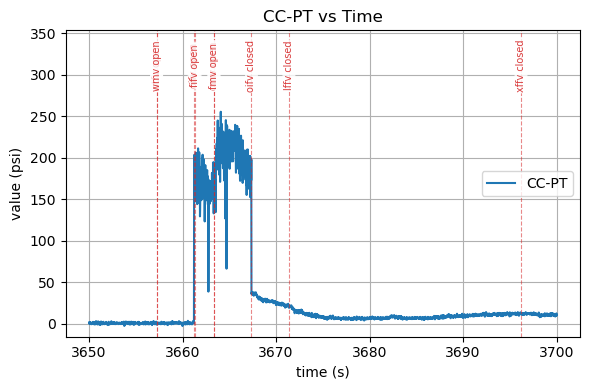

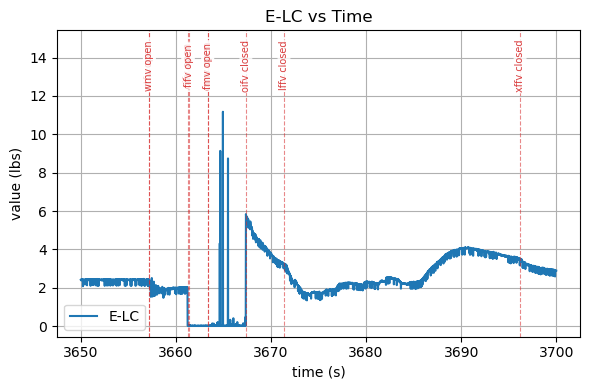

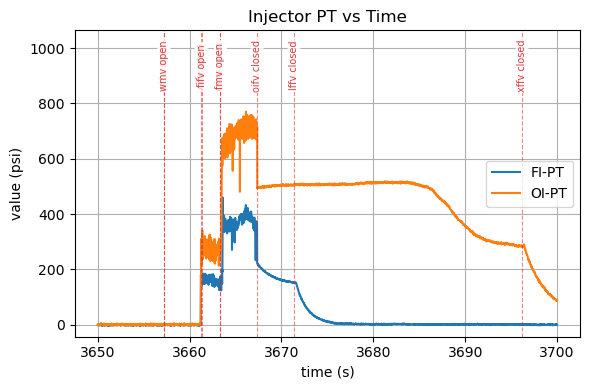

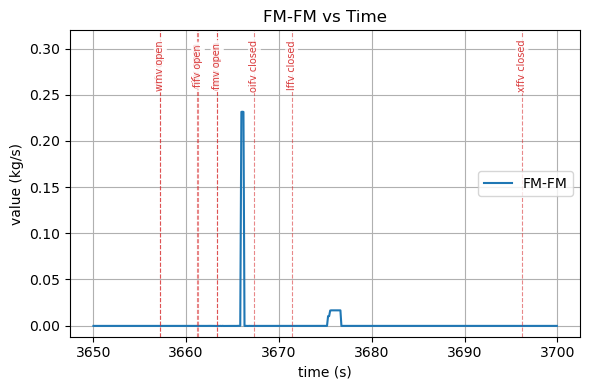

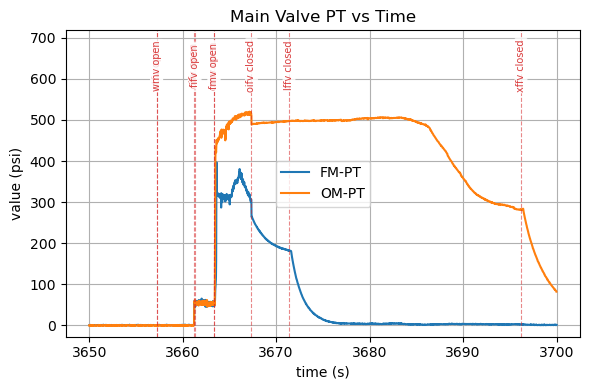

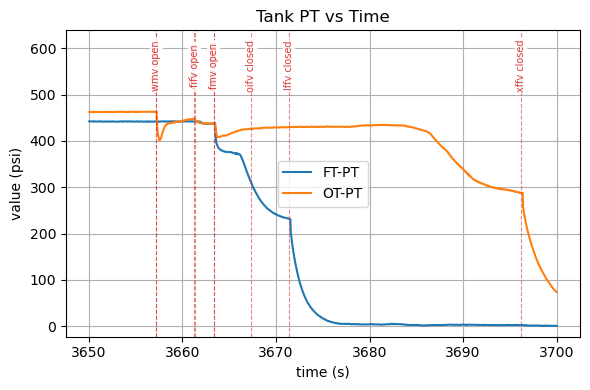

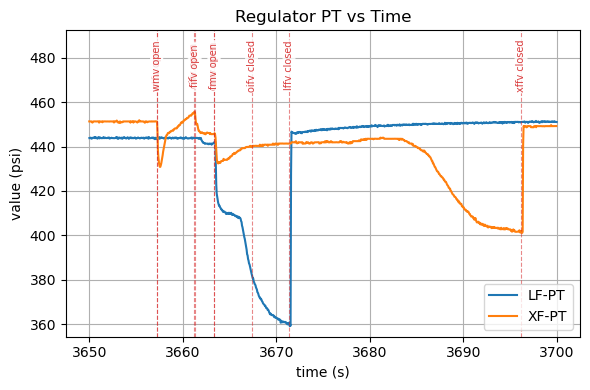

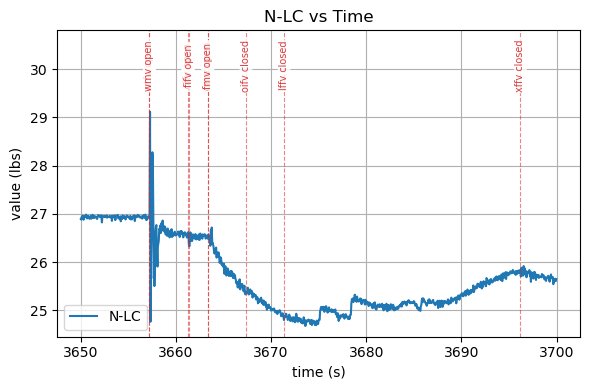

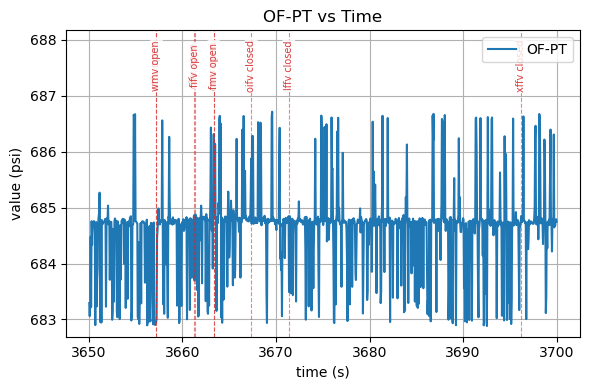

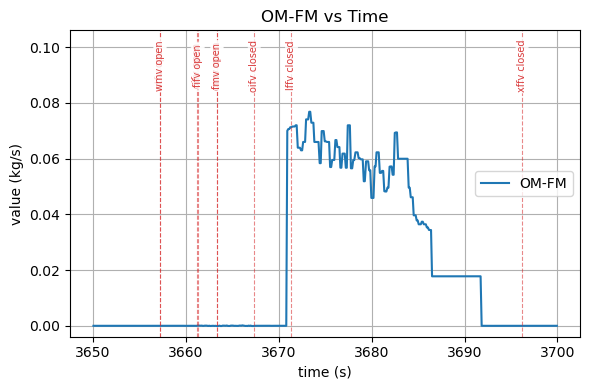

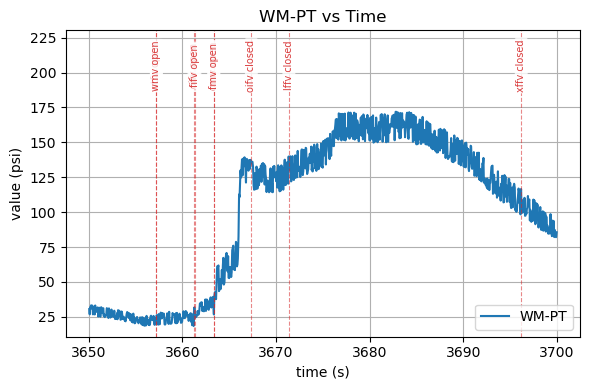

In [7]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

df = pd.read_csv(
    data_paths[0],
    header=0,
    on_bad_lines="skip",
    low_memory=False,
)

da = pd.read_csv(
    actuation_data[0],
    header=0,
    on_bad_lines="skip",
    low_memory=False,
)

df.columns = df.columns.str.strip()
da.columns = da.columns.str.strip()

print("df columns:", df.columns.tolist())
print("da columns:", da.columns.tolist())
print("df shape:", df.shape)
print("da shape:", da.shape)

# Force important columns numeric
for col in ["t_wall", "value", "filtered_value", "V_diff_1", "V_diff_2"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["t_wall", "target_angle"]:
    if col in da.columns:
        da[col] = pd.to_numeric(da[col], errors="coerce")

# Drop rows that cannot be plotted
df = df.dropna(subset=["t_wall", "value", "sensor_name"])
da = da.dropna(subset=["t_wall"])

data_matrix = df.to_numpy()
actuation_matrix = da.to_numpy()


def parse_wall_time(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        return numeric.astype(float), "numeric"

    timestamps = pd.to_datetime(series, errors="coerce")
    if timestamps.notna().any():
        return timestamps, "datetime"

    raise ValueError("t_wall column could not be parsed as numeric or datetime values")


def relative_seconds(time_values, time_kind, t0):
    if time_kind == "datetime":
        return (time_values - t0).dt.total_seconds()
    return time_values - t0


def format_actuation_label(valve_id, target_state=None, target_angle=None):
    if pd.notna(target_state) and str(target_state).strip():
        return f"{valve_id} {target_state}"
    if pd.notna(target_angle):
        return f"{valve_id} {target_angle:g} deg"
    return str(valve_id)


df_wall_time, df_time_kind = parse_wall_time(df["t_wall"])

try:
    da_wall_time, da_time_kind = parse_wall_time(da["t_wall"])
except ValueError:
    print("WARNING: Could not parse actuation t_wall. Plotting sensor data without actuation labels.")
    print("da columns:", da.columns.tolist())
    print(da.head(5).to_string())

    da = pd.DataFrame(columns=["t_rel", "valve_id", "target_state", "target_angle", "action_type"])
    da_wall_time = pd.Series(dtype=float)
    da_time_kind = df_time_kind

if df_time_kind != da_time_kind:
    raise ValueError("df and da t_wall columns were parsed as different time types")

shared_t0 = min(df_wall_time.dropna().min(), da_wall_time.dropna().min())

df["t_rel"] = relative_seconds(df_wall_time, df_time_kind, shared_t0)
da["t_rel"] = relative_seconds(da_wall_time, da_time_kind, shared_t0)

mask_start = 3650
mask_end = 3700

print("df t_rel range:", df["t_rel"].min(), "to", df["t_rel"].max())
print("da t_rel range:", da["t_rel"].min(), "to", da["t_rel"].max())
print("rows in mask:", ((df["t_rel"] > mask_start) & (df["t_rel"] < mask_end)).sum())

if ((df["t_rel"] > mask_start) & (df["t_rel"] < mask_end)).sum() == 0:
    raise ValueError(
        f"No df rows found between {mask_start} and {mask_end} seconds. "
        "Change mask_start/mask_end to be inside the printed t_rel range."
    )

direct_actuation_events = da.sort_values("t_rel")[["t_rel", "valve_id", "target_state", "target_angle"]].copy()
direct_actuation_events["plot_label"] = direct_actuation_events.apply(
    lambda row: format_actuation_label(row["valve_id"], row["target_state"], row["target_angle"]),
    axis=1,
)

action_rows = da.sort_values("t_rel").copy()
action_rows = action_rows[
    action_rows["action_type"].apply(lambda value: isinstance(value, str) and value.startswith("{"))
]
action_rows = action_rows.drop_duplicates(subset=["action_type"], keep="first")

sequence_actuation_events = []

for _, row in action_rows.iterrows():
    action_payload = row["action_type"]

    try:
        action_config = ast.literal_eval(action_payload)
    except (ValueError, SyntaxError):
        continue

    steps = action_config.get("steps", [])
    elapsed_s = 0.0

    for step in steps:
        if not isinstance(step, dict):
            continue

        try:
            step_delay_s = float(step.get("time_delay", 0.0) or 0.0)
        except (TypeError, ValueError):
            step_delay_s = 0.0

        valve_id = step.get("valve_id")
        action = step.get("action")
        target_angle = step.get("angle")

        if action == "throttle" or target_angle is not None:
            event_t_rel = row["t_rel"] + elapsed_s
            sequence_actuation_events.append({
                "t_rel": event_t_rel,
                "valve_id": valve_id,
                "target_state": np.nan,
                "target_angle": target_angle,
                "plot_label": format_actuation_label(valve_id, np.nan, target_angle),
            })

        elapsed_s += step_delay_s

sequence_actuation_events = pd.DataFrame(sequence_actuation_events)

actuation_labels = pd.concat(
    [direct_actuation_events, sequence_actuation_events],
    ignore_index=True,
)

actuation_labels = actuation_labels.sort_values(["t_rel", "plot_label"])
actuation_labels = actuation_labels[
    (actuation_labels["t_rel"] > mask_start)
    & (actuation_labels["t_rel"] < mask_end)
]

shared_plot_groups = {
    "Main Valve PT": {"FM-PT", "OM-PT"},
    "Injector PT": {"FI-PT", "OI-PT"},
    "Regulator PT": {"LF-PT", "XF-PT"},
    "Tank PT": {"FT-PT", "OT-PT"},
}

plot_key_by_sensor = {}
for plot_key, sensor_names in shared_plot_groups.items():
    for sensor_name in sensor_names:
        plot_key_by_sensor[sensor_name.upper()] = plot_key

t, value, raw_value, voltage, units, sensor_type = {}, {}, {}, {}, {}, {}
truncated_series = {}
sampling_rows = []
plot_series = {}

sos = butter(4, 7, fs=100, output="sos")

for name, g in df.groupby("sensor_name"):
    name = str(name).strip()
    g = g.sort_values("t_rel")

    t[name] = g["t_rel"].to_numpy(dtype=float)
    value[name] = g["value"].to_numpy(dtype=float)

    units[name] = g["units"].iloc[0] if "units" in g.columns else ""
    sensor_type[name] = g["sensor_kind"].iloc[0] if "sensor_kind" in g.columns else ""

    # value[name] = sosfiltfilt(sos, value[name])

    if name == "FM-FM":
        # t[name] = t[name] - 6.5
        value[name] = value[name] * 3.785 / 60.0
        units[name] = "kg/s"

    if name == "OM-FM":
        # t[name] = t[name] - 6.5
        value[name] = value[name] * 3.8783637774819204 / 60.0
        units[name] = "kg/s"

        idx = np.argmin(np.abs(t[name] - 4480.0))
        value[name] = value[name] - value[name][idx]

    mask = (t[name] > mask_start) & (t[name] < mask_end)
    t[name] = t[name][mask]
    value[name] = value[name][mask]

    if len(t[name]) == 0:
        continue

    truncated_series[name] = pd.Series(value[name], index=t[name], name=name)

    if len(t[name]) > 1:
        dt_sensor = np.diff(t[name])
        mean_dt = dt_sensor.mean()
        sampling_rate_hz = 1.0 / mean_dt if mean_dt > 0 else np.nan
    else:
        mean_dt = np.nan
        sampling_rate_hz = np.nan

    sampling_rows.append({
        "sensor_name": name,
        "sensor_kind": sensor_type[name],
        "units": units[name],
        "sample_count": len(t[name]),
        "mean_dt_s": mean_dt,
        "sampling_rate_hz": sampling_rate_hz,
    })

    plot_key = plot_key_by_sensor.get(name.upper(), name)
    plot_series.setdefault(plot_key, []).append({
        "sensor_name": name,
        "t": t[name],
        "value": value[name],
        "units": units[name],
    })

print("number of plot groups:", len(plot_series))
print("plot groups:", list(plot_series.keys()))

for plot_key, series_list in plot_series.items():
    fig, ax = plt.subplots(figsize=(6, 4))

    for series in series_list:
        ax.plot(series["t"], series["value"], label=series["sensor_name"])

    y_label_units = series_list[0]["units"]
    ax.set_xlabel("time (s)")
    ax.set_ylabel(f"value ({y_label_units})")

    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min

    if y_span == 0:
        y_span = 1.0

    label_anchor_y = y_min + 1.15 * y_span

    for _, row in actuation_labels.iterrows():
        ax.axvline(row["t_rel"], color="tab:red", linestyle="--", linewidth=0.8, alpha=0.55)
        ax.annotate(
            row["plot_label"],
            xy=(row["t_rel"], label_anchor_y),
            xytext=(0, 0),
            textcoords="offset points",
            rotation=90,
            va="center",
            ha="center",
            fontsize=7,
            color="tab:red",
            alpha=0.9,
            clip_on=False,
            bbox={
                "boxstyle": "round,pad=0.15",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.8,
            },
        )

    ax.set_ylim(y_min, y_max + 0.3 * y_span)
    ax.set_title(f"{plot_key} vs Time")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    plt.show()